# Credit Card Default Prediction

---

## Objective

The objective of this project is to build a machine learning classification model that predicts whether a credit card client will **default on their payment next month**, based on their demographic information, credit data, and past payment history.

Credit card default prediction is an important problem for banks and financial institutions because it helps them:
- Assess credit risk before issuing or renewing credit
- Set appropriate credit limits
- Flag high-risk clients early to reduce financial losses

This is a **binary classification** problem: the target variable `default payment next month` takes the value `1` if the client defaulted and `0` if they did not.

## Data Source

This project uses the **"Default of Credit Card Clients"** dataset, originally published by I-Cheng Yeh and hosted on the **UCI Machine Learning Repository**:
https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

The dataset contains information on **30,000 credit card clients in Taiwan** from April 2005 to September 2005, including:
- Demographic factors: `SEX`, `EDUCATION`, `MARRIAGE`, `AGE`
- Credit data: `LIMIT_BAL` (amount of given credit)
- History of past payments: `PAY_0` to `PAY_6`
- Amount of bill statements: `BILL_AMT1` to `BILL_AMT6`
- Amount of previous payments: `PAY_AMT1` to `PAY_AMT6`
- Target variable: `default payment next month`

The raw file was provided as an Excel workbook (`default of credit card clients.xls`) and is loaded below.

## Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

## Import Data

The original `.xls` file has two header rows (a generic `X1, X2, ...` row and the real column-name row), so we skip the first row when reading it and drop the `ID` column, which is just a row identifier.

In [2]:
df = pd.read_csv('credit_card_default.csv')
df = df.rename(columns={'default payment next month': 'DEFAULT'})
df.head()

   LIMIT_BAL  SEX  EDUCATION  MARRIAGE  ...  PAY_AMT4  PAY_AMT5  PAY_AMT6  DEFAULT
0      20000    2          2         1  ...         0         0         0        1
1     120000    2          2         2  ...      1000         0      2000        1
2      90000    2          2         2  ...      1000      1000      5000        0
3      50000    2          2         1  ...      1100      1069      1000        0
4      50000    1          2         1  ...      9000       689       679        0

[5 rows x 24 columns]


## Describe Data

In [3]:
df.shape

(30000, 24)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_0      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  int64
 21  PAY_AMT5   30000 non-nu

In [5]:
df.describe().T

             count           mean  ...        75%        max
LIMIT_BAL  30000.0  167484.322667  ...  240000.00  1000000.0
SEX        30000.0       1.603733  ...       2.00        2.0
EDUCATION  30000.0       1.853133  ...       2.00        6.0
MARRIAGE   30000.0       1.551867  ...       2.00        3.0
AGE        30000.0      35.485500  ...      41.00       79.0
PAY_0      30000.0      -0.016700  ...       0.00        8.0
PAY_2      30000.0      -0.133767  ...       0.00        8.0
PAY_3      30000.0      -0.166200  ...       0.00        8.0
PAY_4      30000.0      -0.220667  ...       0.00        8.0
PAY_5      30000.0      -0.266200  ...       0.00        8.0
PAY_6      30000.0      -0.291100  ...       0.00        8.0
BILL_AMT1  30000.0   51223.330900  ...   67091.00   964511.0
BILL_AMT2  30000.0   49179.075167  ...   64006.25   983931.0
BILL_AMT3  30000.0   47013.154800  ...   60164.75  1664089.0
BILL_AMT4  30000.0   43262.948967  ...   54506.00   891586.0
BILL_AMT5  30000.0   403

In [6]:
# Check for missing values
df.isnull().sum().sum()

0


In [7]:
# Check for duplicate rows
df.duplicated().sum()

35


In [8]:
df['DEFAULT'].value_counts()
df['DEFAULT'].value_counts(normalize=True) * 100

DEFAULT
0    23364
1     6636
Name: count, dtype: int64
DEFAULT
0    77.88
1    22.12
Name: proportion, dtype: float64


The dataset has **30,000 rows and 24 columns**, no missing values, and no duplicate rows. The target is **imbalanced**: about 78% of clients did not default, while 22% did.

## Data Visualization

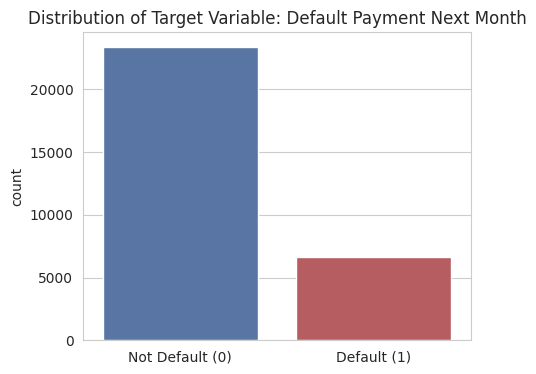

In [9]:
plt.figure(figsize=(5,4))
ax = sns.countplot(x='DEFAULT', data=df, hue='DEFAULT', palette=['#4C72B0','#C44E52'], legend=False)
ax.set_xticks([0,1])
ax.set_xticklabels(['Not Default (0)','Default (1)'])
ax.set_title('Distribution of Target Variable: Default Payment Next Month')
ax.set_xlabel('')
plt.show()

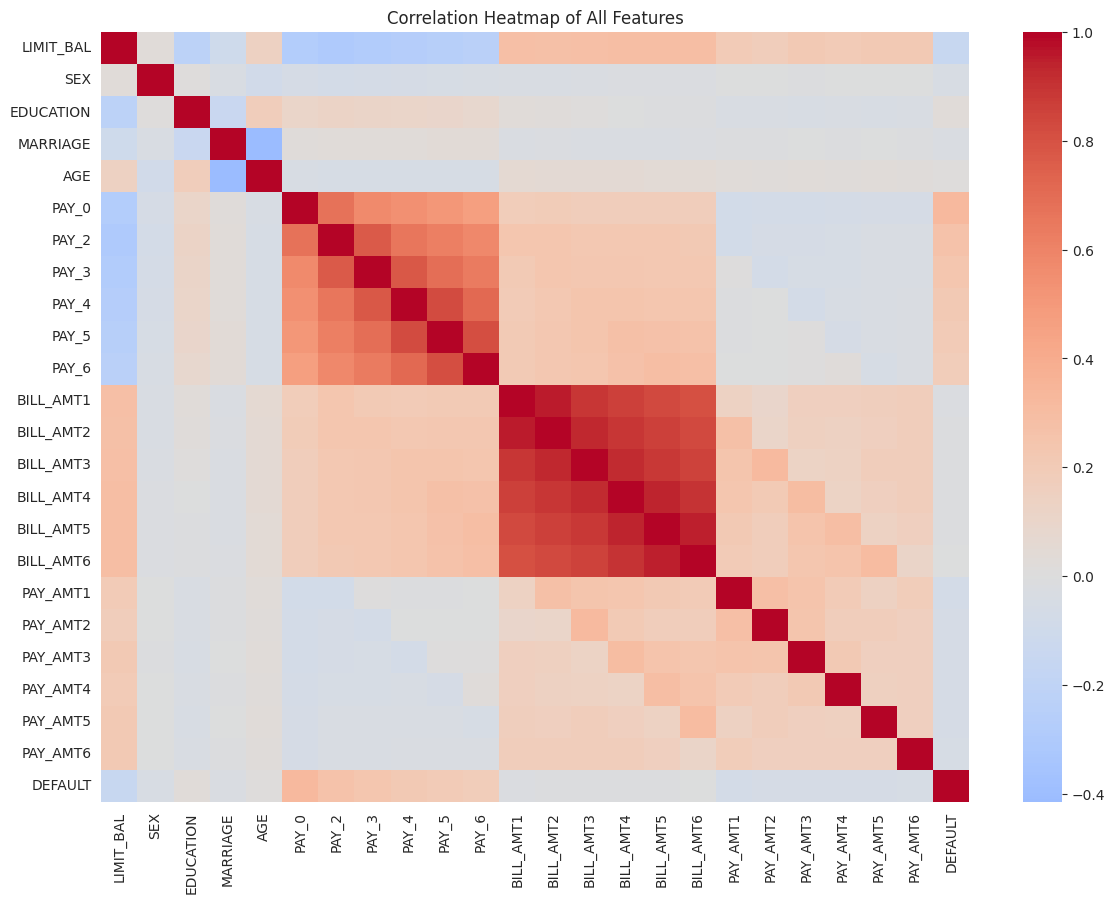

In [10]:
plt.figure(figsize=(14,10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of All Features')
plt.show()

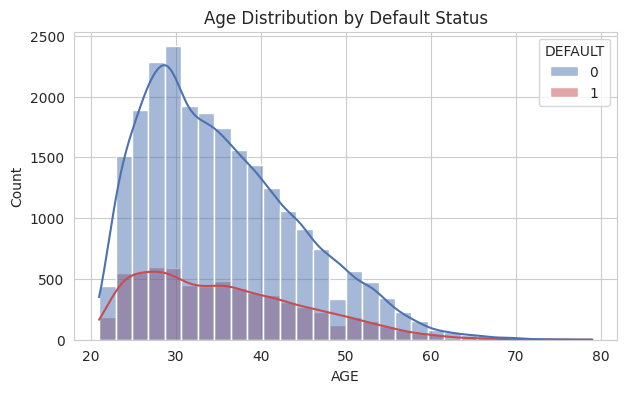

In [11]:
plt.figure(figsize=(7,4))
sns.histplot(data=df, x='AGE', hue='DEFAULT', bins=30, kde=True, palette=['#4C72B0','#C44E52'])
plt.title('Age Distribution by Default Status')
plt.show()

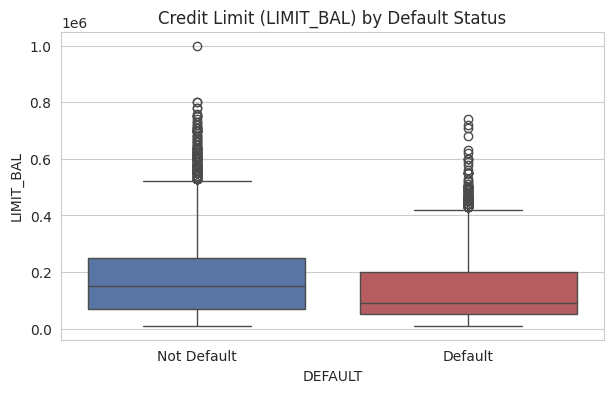

In [12]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='DEFAULT', y='LIMIT_BAL', hue='DEFAULT', palette=['#4C72B0','#C44E52'], legend=False)
plt.xticks([0,1], ['Not Default','Default'])
plt.title('Credit Limit (LIMIT_BAL) by Default Status')
plt.show()

Clients who default tend to have **lower credit limits** on average, and the correlation heatmap shows the `PAY_0`–`PAY_6` (repayment status) features are the most strongly correlated with the target.

## Data Preprocessing

The `EDUCATION` and `MARRIAGE` columns contain undocumented category codes (`0`, `5`, `6` for education; `0` for marriage) that aren't part of the official data dictionary. We group these into the existing "other" category to clean the data.

In [13]:
print("EDUCATION unique before:", sorted(df['EDUCATION'].unique()))
print("MARRIAGE unique before:", sorted(df['MARRIAGE'].unique()))

EDUCATION unique before: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
MARRIAGE unique before: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [14]:
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})   # group unknown/other into category 4
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})                  # group unknown into category 3 (other)

print("EDUCATION unique after:", sorted(df['EDUCATION'].unique()))
print("MARRIAGE unique after:", sorted(df['MARRIAGE'].unique()))

EDUCATION unique after: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE unique after: [np.int64(1), np.int64(2), np.int64(3)]


## Define Target Variable (y) and Feature Variables (X)

In [15]:
X = df.drop(columns=['DEFAULT'])
y = df['DEFAULT']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30000, 23)
y shape: (30000,)


## Train Test Split

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=2529, stratify=y
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("y_train:", y_train.shape, " y_test:", y_test.shape)

X_train: (22500, 23)  X_test: (7500, 23)
y_train: (22500,)  y_test: (7500,)


`stratify=y` is used so the 78/22 class balance is preserved in both the train and test sets.

## Modeling

Two models are trained and compared:
1. **Logistic Regression** (on standardized features) — a simple, interpretable baseline
2. **Random Forest Classifier** (on raw features) — a stronger, non-linear model

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Logistic Regression

In [18]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=2529)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

### Random Forest Classifier

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=2529, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

## Model Evaluation

### Logistic Regression Evaluation

In [20]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("Logistic Regression Accuracy:", round(accuracy_score(y_test, y_pred_log), 4))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.8163

Confusion Matrix:
[[5715  126]
 [1252  407]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.98      0.89      5841
           1       0.76      0.25      0.37      1659

    accuracy                           0.82      7500
   macro avg       0.79      0.61      0.63      7500
weighted avg       0.81      0.82      0.78      7500



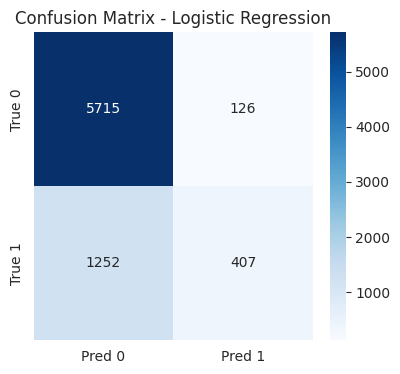

In [21]:
plt.figure(figsize=(4.5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'])
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

### Random Forest Evaluation

In [22]:
print("Random Forest Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8291

Confusion Matrix:
[[5606  235]
 [1047  612]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.96      0.90      5841
           1       0.72      0.37      0.49      1659

    accuracy                           0.83      7500
   macro avg       0.78      0.66      0.69      7500
weighted avg       0.82      0.83      0.81      7500



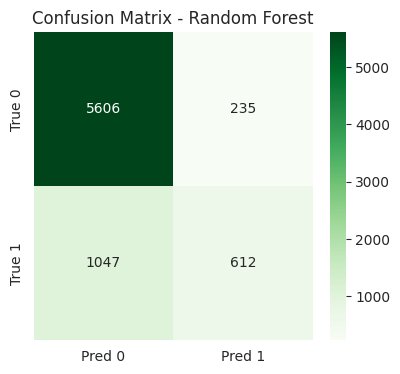

In [23]:
plt.figure(figsize=(4.5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'])
plt.title('Confusion Matrix - Random Forest')
plt.show()

### Feature Importance (Random Forest)

PAY_0        0.314489
PAY_2        0.126885
PAY_3        0.072890
PAY_5        0.057234
PAY_4        0.049537
PAY_6        0.039138
PAY_AMT1     0.035422
LIMIT_BAL    0.029540
PAY_AMT2     0.028907
BILL_AMT1    0.028869
dtype: float64


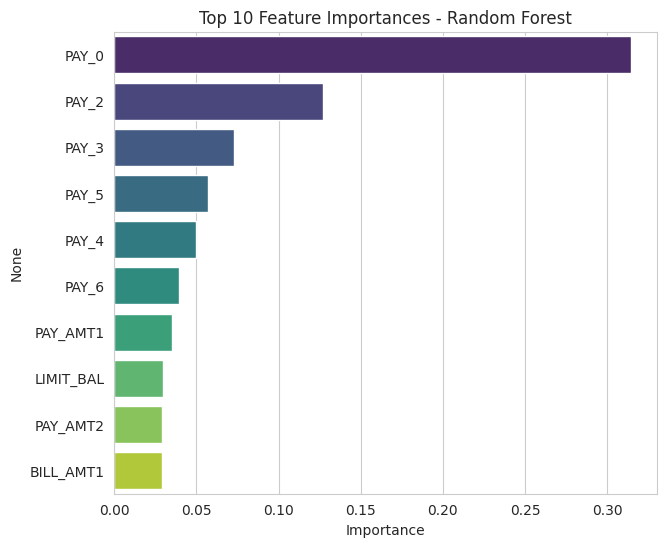

In [24]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7,6))
sns.barplot(x=importances.values[:10], y=importances.index[:10], hue=importances.index[:10],
            palette='viridis', legend=False)
plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.show()

importances.head(10)

**Random Forest slightly outperforms Logistic Regression** on overall accuracy and, notably, on recall/F1 for the minority "default" class. `PAY_0` (the most recent repayment status) is by far the most important predictor, followed by the other recent `PAY_x` and `LIMIT_BAL` features — confirming that recent payment behavior is the strongest signal of future default.

## Prediction

In [25]:
# Predict on a single client from the test set
sample = X_test.iloc[[0]]
pred_sample = rf_model.predict(sample)[0]
prob_sample = rf_model.predict_proba(sample)[0]

print("Sample input:")
print(sample)
print()
print("Predicted class:", pred_sample, "(1 = Default, 0 = Not Default)")
print("Prediction probability [Not Default, Default]:", np.round(prob_sample, 3))
print("Actual class:", y_test.iloc[0])

Sample input:
      LIMIT_BAL  SEX  EDUCATION  ...  PAY_AMT4  PAY_AMT5  PAY_AMT6
3580     300000    1          1  ...       468       366         0

[1 rows x 23 columns]

Predicted class: 0 (1 = Default, 0 = Not Default)
Prediction probability [Not Default, Default]: [0.802 0.198]
Actual class: 1


## Explanation

- The dataset is **imbalanced** (~78% non-default vs ~22% default), which is why accuracy alone is not the best metric — precision, recall, and F1-score for the "default" class matter more.
- Both models predict the majority class well (recall ≈ 0.96–0.98 for "not default") but struggle more to catch actual defaulters (recall ≈ 0.25–0.37 for "default"), which is typical for imbalanced credit risk data.
- **Random Forest (≈83% accuracy)** outperforms **Logistic Regression (≈82% accuracy)**, especially in identifying defaulters (higher recall and F1 for class 1).
- The **repayment status features (`PAY_0`–`PAY_6`)** are the strongest predictors of default — a client who was already late on recent payments is much more likely to default next month than one who was on time, regardless of their credit limit or bill amount.
- **Next steps** to improve this model further could include: handling class imbalance (e.g. SMOTE or class weighting), hyperparameter tuning, trying gradient boosting models (XGBoost/LightGBM), and engineering features like average utilization ratio or payment-to-bill ratio.